In [56]:
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import shap
import matplotlib.pyplot as plt

shap.initjs()

In [57]:
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [58]:
query = """
SELECT
    sc.user_id,
    sc.date AS month,
    sct.period,
    sct."secondsPlayed" AS seconds
FROM "SoundCapsule" sc
JOIN "SoundCapsule_TimeOfDayStats" sct
ON sc.id = sct.soundcapsule_id
ORDER BY sc.user_id, sc.date
"""

df = pd.read_sql(query, engine)

# Garantir datetime
df["month"] = pd.to_datetime(df["month"])

In [59]:
df_pivot = df.pivot_table(
    index=["user_id", "month"],
    columns="period",
    values="seconds",
    fill_value=0
).reset_index()

period_cols = [
    col for col in df_pivot.columns
    if col not in ["user_id", "month"]
]

In [60]:
df_pivot["total_seconds"] = df_pivot[period_cols].sum(axis=1)

for col in period_cols:
    df_pivot[f"pct_{col}"] = df_pivot[col] / df_pivot["total_seconds"]

df_pivot.fillna(0, inplace=True)

period,user_id,month,afternoon,early_morning,evening,late_evening,morning,night,total_seconds,pct_afternoon,pct_early_morning,pct_evening,pct_late_evening,pct_morning,pct_night
0,1,2025-10-01,309.0,2021.0,0.0,222.0,5102.0,0.0,7654.0,0.040371,0.264045,0.000000,0.029004,0.666580,0.000000
1,1,2025-11-01,18399.0,7829.0,10934.0,7842.0,7207.0,12766.0,64977.0,0.283162,0.120489,0.168275,0.120689,0.110916,0.196470
2,1,2025-12-01,715.0,0.0,338.0,3507.0,1662.0,0.0,6222.0,0.114915,0.000000,0.054323,0.563645,0.267117,0.000000
3,1,2026-01-01,13393.0,3544.0,4556.0,0.0,23871.0,0.0,45364.0,0.295234,0.078124,0.100432,0.000000,0.526210,0.000000
4,2,2025-10-01,10689.0,3055.0,3622.0,0.0,5795.0,0.0,23161.0,0.461509,0.131903,0.156384,0.000000,0.250205,0.000000
5,2,2025-11-01,22666.0,2562.0,518.0,240.0,2059.0,0.0,28045.0,0.808201,0.091353,0.018470,0.008558,0.073418,0.000000
6,2,2025-12-01,0.0,1373.0,0.0,0.0,1735.0,0.0,3108.0,0.000000,0.441763,0.000000,0.000000,0.558237,0.000000
7,2,2026-01-01,1473.0,1582.0,0.0,0.0,4757.0,0.0,7812.0,0.188556,0.202509,0.000000,0.000000,0.608935,0.000000
8,3,2025-10-01,30501.0,0.0,64787.0,24751.0,853.0,4686.0,125578.0,0.242885,0.000000,0.515910,0.197097,0.006793,0.037315
9,3,2025-11-01,24095.0,1490.0,41896.0,15234.0,14316.0,4773.0,101804.0,0.236680,0.014636,0.411536,0.149640,0.140623,0.046884


In [61]:
df_pivot = df_pivot.sort_values(["user_id", "month"])

for col in period_cols:
    df_pivot[f"delta_{col}"] = (
        df_pivot
        .groupby("user_id")[f"pct_{col}"]
        .diff()
    )

df_pivot.fillna(0, inplace=True)

period,user_id,month,afternoon,early_morning,evening,late_evening,morning,night,total_seconds,pct_afternoon,...,pct_evening,pct_late_evening,pct_morning,pct_night,delta_afternoon,delta_early_morning,delta_evening,delta_late_evening,delta_morning,delta_night
0,1,2025-10-01,309.0,2021.0,0.0,222.0,5102.0,0.0,7654.0,0.040371,...,0.000000,0.029004,0.666580,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2025-11-01,18399.0,7829.0,10934.0,7842.0,7207.0,12766.0,64977.0,0.283162,...,0.168275,0.120689,0.110916,0.196470,0.242791,-0.143556,0.168275,0.091684,-0.555663,0.196470
2,1,2025-12-01,715.0,0.0,338.0,3507.0,1662.0,0.0,6222.0,0.114915,...,0.054323,0.563645,0.267117,0.000000,-0.168247,-0.120489,-0.113952,0.442956,0.156201,-0.196470
3,1,2026-01-01,13393.0,3544.0,4556.0,0.0,23871.0,0.0,45364.0,0.295234,...,0.100432,0.000000,0.526210,0.000000,0.180319,0.078124,0.046109,-0.563645,0.259094,0.000000
4,2,2025-10-01,10689.0,3055.0,3622.0,0.0,5795.0,0.0,23161.0,0.461509,...,0.156384,0.000000,0.250205,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2,2025-11-01,22666.0,2562.0,518.0,240.0,2059.0,0.0,28045.0,0.808201,...,0.018470,0.008558,0.073418,0.000000,0.346693,-0.040550,-0.137913,0.008558,-0.176787,0.000000
6,2,2025-12-01,0.0,1373.0,0.0,0.0,1735.0,0.0,3108.0,0.000000,...,0.000000,0.000000,0.558237,0.000000,-0.808201,0.350410,-0.018470,-0.008558,0.484819,0.000000
7,2,2026-01-01,1473.0,1582.0,0.0,0.0,4757.0,0.0,7812.0,0.188556,...,0.000000,0.000000,0.608935,0.000000,0.188556,-0.239254,0.000000,0.000000,0.050698,0.000000
8,3,2025-10-01,30501.0,0.0,64787.0,24751.0,853.0,4686.0,125578.0,0.242885,...,0.515910,0.197097,0.006793,0.037315,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,3,2025-11-01,24095.0,1490.0,41896.0,15234.0,14316.0,4773.0,101804.0,0.236680,...,0.411536,0.149640,0.140623,0.046884,-0.006205,0.014636,-0.104375,-0.047456,0.133831,0.009569


In [62]:
day_periods = ["morning", "afternoon"]
night_periods = ["evening", "late_evening"]

df_pivot["dominant_period"] = df_pivot[period_cols].idxmax(axis=1)

df_pivot["dominant_binary"] = df_pivot["dominant_period"].apply(
    lambda x: "day" if x in day_periods else "night"
)

# Target = próximo mês
df_pivot["target"] = (
    df_pivot
    .groupby("user_id")["dominant_binary"]
    .shift(-1)
)

df_pivot = df_pivot.dropna(subset=["target"])

In [63]:
df_pivot["current_binary"] = df_pivot["dominant_binary"].map(
    {"day": 0, "night": 1}
)

In [64]:

le = LabelEncoder()
df_pivot["target_encoded"] = le.fit_transform(df_pivot["target"])

In [65]:
feature_cols = []

for col in period_cols:
    feature_cols.append(f"pct_{col}")
    feature_cols.append(f"delta_{col}")

feature_cols.append("current_binary")


In [66]:
# Ordenar por mês
df_pivot = df_pivot.sort_values("month")

# Definir 70% treino / 30% teste baseado na ordem temporal
split_index = int(len(df_pivot) * 0.7)

train = df_pivot.iloc[:split_index]
test = df_pivot.iloc[split_index:]

X_train = train[feature_cols]
y_train = train["target_encoded"]

X_test = test[feature_cols]
y_test = test["target_encoded"]

print("Treino:", len(train))
print("Teste:", len(test))


Treino: 10
Teste: 5


In [67]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [68]:
preds = model.predict(X_test)

print("\n MODELO ")
print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    preds,
    labels=[0, 1],
    target_names=le.classes_,
    zero_division=0
))


 MODELO 
Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

         day       1.00      0.80      0.89         5
       night       0.00      0.00      0.00         0

    accuracy                           0.80         5
   macro avg       0.50      0.40      0.44         5
weighted avg       1.00      0.80      0.89         5



In [69]:
latest_month = df_pivot["month"].max()

latest_data = df_pivot[df_pivot["month"] == latest_month].copy()

X_latest = latest_data[feature_cols]

pred_encoded = model.predict(X_latest)

latest_data["predicted_next_month"] = le.inverse_transform(pred_encoded)

print("\nPREVISÃO PRÓXIMO MÊSn")
print(latest_data[["user_id", "predicted_next_month"]])


PREVISÃO PRÓXIMO MÊSn
period  user_id predicted_next_month
2             1                  day
6             2                  day
10            3                night
14            4                  day
18            5                  day



COEFICIENTES DO MODELO

                feature  coefficient
12       current_binary     0.965988
4           pct_evening     0.367096
6      pct_late_evening     0.195299
10            pct_night     0.166282
11          delta_night     0.133700
5         delta_evening     0.095637
1       delta_afternoon     0.046762
7    delta_late_evening     0.044863
3   delta_early_morning    -0.054463
2     pct_early_morning    -0.120417
8           pct_morning    -0.217313
9         delta_morning    -0.266499
0         pct_afternoon    -0.391146


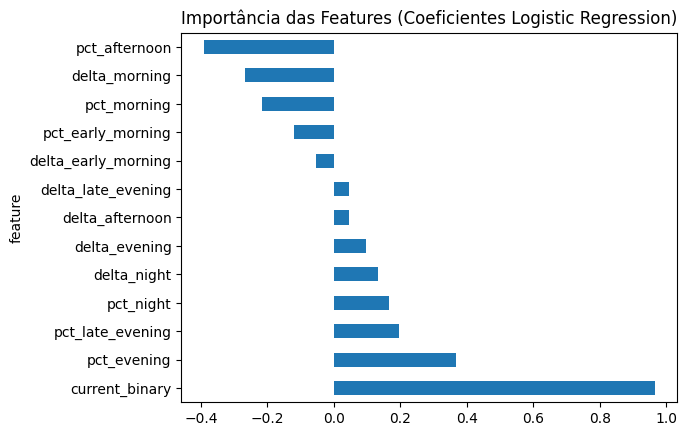

In [70]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nCOEFICIENTES DO MODELO\n")
print(coef_df)

# Plot coeficientes
plt.figure()
coef_df.set_index("feature")["coefficient"].plot(kind="barh")
plt.title("Importância das Features (Coeficientes Logistic Regression)")
plt.show()

c:\Users\ruanlourenco-ieg\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


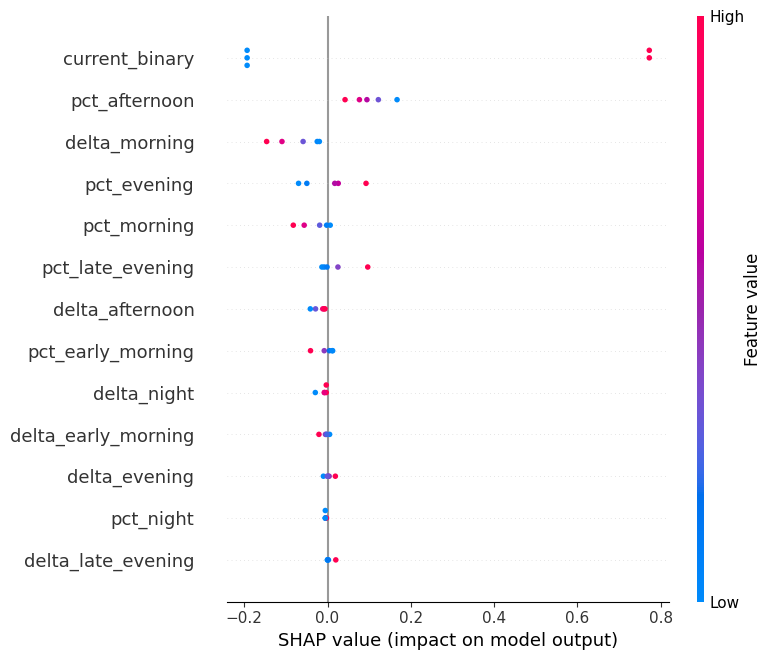

In [71]:
explainer = shap.LinearExplainer(
    model,
    X_train,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_cols
)


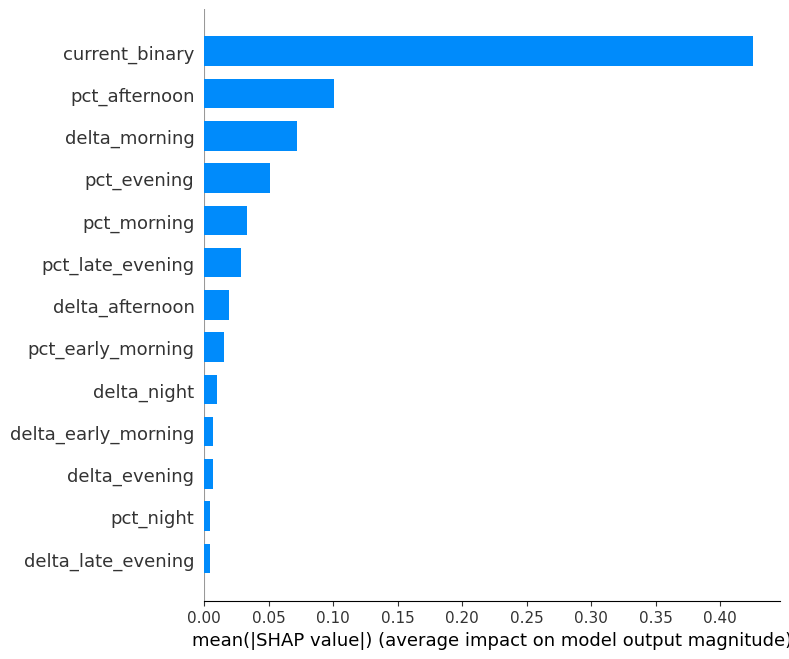

In [72]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_cols,
    plot_type="bar"
)
